# Classificador de Kanji N1 — Treino (ResNet-18)

Notebook de treino do classificador (etapa 2 do pipeline detector → classificador N1 → filtro N1). Gera o dataset sintético de crops (1232 kanji N1, fontes + degradações + fundo real de manga), gera e mescla dado real alinhado do Manga109 (N1 + OUTROS reais), gera o conjunto de validação real de N1 (filtrado por manga-ocr), treina um ResNet-18 pré-treinado no ImageNet, e avalia no split de validação.

**Checklist antes de rodar:**
1. Habilite a GPU: *Session options → Accelerator → GPU T4 x2 ou P100*.
2. **Anexe o dataset `backgrounds-real`** (pastas `claro/`+`escuro/` — ver `src/helper/harvest_backgrounds.py`).
3. **Anexe o dataset do Manga109** (imagens + anotações completas).
4. **Run All**.

Os pesos do detector (`weights/best.pt`) já vêm no clone do repositório — não precisa de dataset separado pra isso. Sem os datasets anexados, cada etapa cai automaticamente no fallback (fundo sintético / só dado sintético) e avisa no log — não trava, mas perde o benefício do dado real.

As fontes (15) são baixadas automaticamente.

In [1]:
import subprocess
result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "GPU nao encontrada!")

Sat Aug  8 19:05:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 596.49                 Driver Version: 596.49         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   53C    P8              6W /   35W |    1226MiB /   6144MiB |     14%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Parâmetros do experimento

**Altere apenas esta célula** para controlar o experimento inteiro. As variáveis `KD_*` são lidas por `config.py` via `os.environ`.

In [2]:
import os

# --- Geracao do dataset sintetico (crops por classe) ---
SAMPLES_TRAIN = 200
SAMPLES_VAL   = 40

# Sim = mescla dado real do Manga109 na classe OUTROS (comportamento historico).
# Nao = OUTROS 100% sintetico -- testa a hipotese de que ter real SO no OUTROS
# ensina um atalho "parece foto real -> OUTROS" em vez de reconhecer o kanji
# (ver EXPERIMENTS.md "Validacao real de N1", achado de 2026-08-02: modelo previu
# OUTROS em 95% das imagens reais de N1, mas acertou 100% das vezes que arriscou
# um kanji especifico -- sinal de atalho de dominio, nao de classificador ruim).
OUTROS_REAL_MIX = False   # False = OUTROS so sintetico

# Continua o treino a partir de um checkpoint existente em vez de do zero
# (ex: retomar um treino que rodou parcialmente no Kaggle/local antes de
# ser interrompido). "" = treino do zero.
FINETUNE_FROM = ""

# --- Modelo ---
MODEL_ARCH    = "resnet18"   # ou "efficientnet_b0"
PRETRAINED    = True
STEM_LEVE     = True   # continuando o treino ja convergido antes (epoca 5) ate convergir de verdade
LABEL_SMOOTHING = 0.1  # experimento: label smoothing na CrossEntropyLoss (0.0 = comportamento antigo)

# --- Treino ---
EPOCHS        = 50
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 7            # early stopping
BATCH_SIZE    = 128

# ============================================================
# Aplica as configuracoes como variaveis de ambiente
# ============================================================
os.environ["KD_CLF_SAMPLES_TRAIN"] = str(SAMPLES_TRAIN)
os.environ["KD_CLF_SAMPLES_VAL"]   = str(SAMPLES_VAL)
os.environ["KD_CLF_MODEL_ARCH"]    = str(MODEL_ARCH)
os.environ["KD_CLF_PRETRAINED"]    = str(PRETRAINED)
os.environ["KD_CLF_STEM_LEVE"]     = str(STEM_LEVE)
os.environ["KD_CLF_LABEL_SMOOTHING"] = str(LABEL_SMOOTHING)
os.environ["KD_CLF_EPOCHS"]        = str(EPOCHS)
os.environ["KD_CLF_LR"]            = str(LR)
os.environ["KD_CLF_WEIGHT_DECAY"]  = str(WEIGHT_DECAY)
os.environ["KD_CLF_PATIENCE"]      = str(PATIENCE)
os.environ["KD_CLF_BATCH_SIZE"]    = str(BATCH_SIZE)
os.environ["KD_OUTROS_REAL_MIX"] = str(OUTROS_REAL_MIX)
if FINETUNE_FROM:
    os.environ["KD_CLF_FINETUNE_FROM"] = FINETUNE_FROM

print("Parametros registrados!")
print(f"  Modelo: {MODEL_ARCH} (pretrained={PRETRAINED}, stem_leve={STEM_LEVE})")
print(f"  Epochs: {EPOCHS} | LR: {LR} | Patience: {PATIENCE} | Batch: {BATCH_SIZE} | Label smoothing: {LABEL_SMOOTHING}")
print(f"  Amostras/classe: {SAMPLES_TRAIN} treino + {SAMPLES_VAL} val")
print(f"  OUTROS com dado real do Manga109: {OUTROS_REAL_MIX}")
print(f"  Finetune de: {FINETUNE_FROM or '(treino do zero)'}")


Parametros registrados!
  Modelo: resnet18 (pretrained=True, stem_leve=True)
  Epochs: 50 | LR: 0.0003 | Patience: 7 | Batch: 128 | Label smoothing: 0.1
  Amostras/classe: 200 treino + 40 val
  OUTROS com dado real do Manga109: False
  Finetune de: weights/backups/classifier_best_stem.pt


## 2. Instalar dependências

In [3]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "tqdm", "scipy", "fonttools", "ultralytics", "manga-ocr"], check=True)
print("Dependencias instaladas.")


Dependencias instaladas.


## 3. Configurar repositório

Clona (ou atualiza) o repositório com o código do pipeline em `/kaggle/working/` e adiciona ao `sys.path`.

In [4]:
import os
import sys
import shutil
import subprocess

IS_KAGGLE = os.path.exists("/kaggle/input") or "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IS_KAGGLE:
    WORK_DIR  = "/kaggle/working"
    REPO_NAME = "Detector-de-kanjis-n1"
    REPO_DIR  = os.path.join(WORK_DIR, REPO_NAME)
    REPO_URL  = f"https://github.com/MiguelMussalam/{REPO_NAME}.git"

    is_valid_repo = os.path.isdir(os.path.join(REPO_DIR, ".git"))

    if not is_valid_repo:
        if os.path.exists(REPO_DIR):
            print(f"Diretorio {REPO_DIR} existe mas nao e um repo git valido. Removendo...")
            shutil.rmtree(REPO_DIR)
        print(f"Clonando {REPO_URL} ...")
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    else:
        print("Repo valido encontrado. Atualizando...")
        subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)
else:
    # Local: sobe a partir do diretorio atual ate achar a raiz do repo
    # (config.py na raiz) -- ja estamos no repo, sem clone/pull.
    candidato = os.getcwd()
    while not os.path.isfile(os.path.join(candidato, "config.py")):
        pai = os.path.dirname(candidato)
        if pai == candidato:
            raise RuntimeError(
                f"Nao achei a raiz do repo (config.py) subindo a partir de {os.getcwd()}"
            )
        candidato = pai
    REPO_DIR = candidato
    print(f"Ambiente local detectado. Usando repo existente em {REPO_DIR} (sem clone/pull).")

assert os.path.isfile(os.path.join(REPO_DIR, "config.py")), \
    f"config.py nao encontrado em {REPO_DIR} \u2014 verifique se o clone/deteccao funcionou"

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

from config import CLF_PROJECT_NAME

print(f"Diretorio de trabalho: {os.getcwd()}")
print(f"Project name (runs):   {CLF_PROJECT_NAME}")


Ambiente local detectado. Usando repo existente em C:\IC - OCR\Detector-de-kanjis-n1 (sem clone/pull).
Diretorio de trabalho: C:\IC - OCR\Detector-de-kanjis-n1
Project name (runs):   kanji_classifier


## 4. Baixar fontes e gerar dataset de crops

Baixa as 15 fontes usadas na renderização e gera o dataset sintético completo (1232 kanji N1 × amostras/classe definidas na Célula 1), usando fundo real do Manga109 (dataset `backgrounds-real` anexado) quando disponível. Leva ~15-25 minutos.

In [5]:
from config import FONTES_URL, FONTS_DIR, BACKGROUNDS_REAL_DIR, CLASSIFIER_TRAIN_DIR
import os

from src.helper.fonts import download_fonts
print("[INFO] Baixando fontes...")
download_fonts(FONTES_URL, FONTS_DIR)

tem_claro = os.path.isdir(os.path.join(BACKGROUNDS_REAL_DIR, "claro"))
tem_escuro = os.path.isdir(os.path.join(BACKGROUNDS_REAL_DIR, "escuro"))
if tem_claro and tem_escuro:
    n_claro = len(os.listdir(os.path.join(BACKGROUNDS_REAL_DIR, "claro")))
    n_escuro = len(os.listdir(os.path.join(BACKGROUNDS_REAL_DIR, "escuro")))
    print(f"[INFO] Fundo real encontrado: {BACKGROUNDS_REAL_DIR} ({n_claro} claros, {n_escuro} escuros)")
else:
    print(f"[AVISO] Dataset 'backgrounds-real' nao encontrado em {BACKGROUNDS_REAL_DIR}. "
          f"Anexe o dataset (Add Input) para usar fundo real -- sem ele, o gerador cai "
          f"no fundo sintetico antigo (papel liso).")

n_classes_existentes = len(os.listdir(CLASSIFIER_TRAIN_DIR)) if os.path.isdir(CLASSIFIER_TRAIN_DIR) else 0
if n_classes_existentes >= 1233:
    print(f"[INFO] Dataset sintetico ja existe ({n_classes_existentes} classes) -- pulando geracao. "
          f"Apague {CLASSIFIER_TRAIN_DIR} pra regenerar do zero.")
else:
    print("[INFO] Gerando dataset de crops (isso demora, ~15-25 min)...")
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "src.classifier.generate_crops"], check=True)


[INFO] Baixando fontes...
Shippori Antique já existe, pulando
Klee-One-Regular já existe, pulando
Yusei-Magic-Regular já existe, pulando
Dela-Gothic-One já existe, pulando
Reggae-One já existe, pulando
Yuji-Boku-Regular já existe, pulando
Zen-Antique-Regular já existe, pulando
Kaisei-Tokumin-W5 já existe, pulando
Hachi-Maru-Pop-Regular já existe, pulando
Stick-Regular já existe, pulando
GenEi-Antique-M já existe, pulando
GenEi-Gothic-KL-H já existe, pulando
[INFO] Fundo real encontrado: C:\IC - OCR\Detector-de-kanjis-n1\data\backgrounds_real (4000 claros, 300 escuros)
[INFO] Dataset sintetico ja existe (1233 classes) -- pulando geracao. Apague C:\IC - OCR\Detector-de-kanjis-n1\data\classifier\train pra regenerar do zero.


## 4.5 Gerar dado real do Manga109 (N1 + OUTROS) e mesclar

Roda o alinhamento (`manga109_align.py`) direto aqui -- usa o dataset Manga109 anexado (imagens+anotacoes) e os pesos do detector (`weights/best.pt`, já vem no clone do repositório). Não depende de nenhum dataset pré-processado: gera o dado real do zero a cada run, então qualquer ajuste no alinhamento (ex: `MANGA109_ALIGN_GAP_Y_FATOR`) já vale na próxima vez sem precisar re-empacotar nada. Depois mescla com o dataset sintético via `merge_real_data.py` (OUTROS real subamostrado a 20k/5k). Controlado pelo toggle `OUTROS_REAL_MIX` da Célula 1 -- com `False`, esta célula gera o alinhamento só pra registro/depuração mas não mescla no dataset de treino (OUTROS fica 100% sintético).

In [6]:
import os
from config import MANGA109_DIR, MANGA109_IMAGES, MANGA109_ANNOTATIONS, DETECTOR_WEIGHTS_PATH

outros_real_mix = os.environ.get("KD_OUTROS_REAL_MIX", "True") == "True"
tem_manga109 = os.path.isdir(MANGA109_IMAGES) and os.path.isdir(MANGA109_ANNOTATIONS)
tem_detector = os.path.exists(DETECTOR_WEIGHTS_PATH)

if not outros_real_mix:
    print("[INFO] OUTROS_REAL_MIX=False -- pulando geracao/mesclagem de dado real. "
          "OUTROS fica 100% sintetico.")
elif not tem_manga109:
    print(f"[AVISO] Manga109 nao encontrado ({MANGA109_DIR}). Anexe o dataset (Add Input) "
          f"para gerar dado real -- sem ele, o treino segue so com dado sintetico.")
elif not tem_detector:
    print(f"[AVISO] Pesos do detector nao encontrados em {DETECTOR_WEIGHTS_PATH}. "
          f"Verifique se weights/best.pt veio no clone do repositorio.")
else:
    print(f"[INFO] Manga109 encontrado em: {MANGA109_DIR}")
    print(f"[INFO] Detector encontrado em: {DETECTOR_WEIGHTS_PATH}")
    print("[INFO] Rodando alinhamento (isso demora, depende do tamanho do corpus)...")
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "src.helper.manga109_align"], check=True)
    print("\n[INFO] Mesclando dado real com o dataset sintetico...")
    subprocess.run([sys.executable, "-m", "src.classifier.merge_real_data"], check=True)


[INFO] OUTROS_REAL_MIX=False -- pulando geracao/mesclagem de dado real. OUTROS fica 100% sintetico.


## 4.6 Gerar validação real de N1 (manga-ocr)

Gera o conjunto de validação REAL de kanji N1 (`src/helper/manga109_align_n1.py`) -- mesma heurística de alinhamento, mas guardando N1 em vez de descartar, filtrado por concordância com o manga-ocr (reduz o erro residual de alinhamento de ~6% pra ~0% numa amostra de auditoria -- ver `EXPERIMENTS.md` "Validação real de N1"). `train.py` usa esse conjunto pra escolher o `best.pt` em vez do `val_acc` sintético quando ele existir -- sem ele, cai de volta pro comportamento antigo. Usa o mesmo Manga109 e detector já anexados/clonados nos passos anteriores, sem dataset extra. Leva alguns minutos (roda o detector + manga-ocr por página, ~109 volumes).


In [7]:
import os
from config import MANGA109_DIR, MANGA109_IMAGES, MANGA109_ANNOTATIONS, DETECTOR_WEIGHTS_PATH, MANGA109_ALIGN_N1_DIR

tem_manga109 = os.path.isdir(MANGA109_IMAGES) and os.path.isdir(MANGA109_ANNOTATIONS)
tem_detector = os.path.exists(DETECTOR_WEIGHTS_PATH)
ja_existe = os.path.isdir(MANGA109_ALIGN_N1_DIR) and len(os.listdir(MANGA109_ALIGN_N1_DIR)) > 100

if ja_existe:
    print(f"[INFO] Conjunto real de N1 ja existe ({len(os.listdir(MANGA109_ALIGN_N1_DIR))} classes) -- pulando geracao. "
          f"Apague {MANGA109_ALIGN_N1_DIR} pra regenerar do zero.")
elif not tem_manga109:
    print(f"[AVISO] Manga109 nao encontrado ({MANGA109_DIR}). Sem ele, train.py cai "
          f"de volta pro val_acc sintetico pra escolher o best.pt.")
elif not tem_detector:
    print(f"[AVISO] Pesos do detector nao encontrados em {DETECTOR_WEIGHTS_PATH}.")
else:
    print("[INFO] Gerando validacao real de N1 (heuristica + filtro manga-ocr)...")
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "src.helper.manga109_align_n1"], check=True)


[INFO] Conjunto real de N1 ja existe (637 classes) -- pulando geracao. Apague C:\IC - OCR\Detector-de-kanjis-n1\data\classifier_real_n1 pra regenerar do zero.


## 5. Verificar dataset + inspeção visual (sanity)

Antes de treinar, confira visualmente algumas amostras sintéticas geradas.

Classes em train: 1233 | Classes em val: 1233

Mostrando 8 amostras sanity:
000_U+5BC6_Dela-Gothic-One_22.png


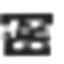

001_U+7DB2_Zen-Antique-Reg_16.png


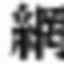

002_U+75C7_Dela-Gothic-One_22.png


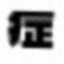

003_U+7D5E_Hachi-Maru-Pop-_28.png


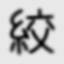

004_U+6276_Stick-Regular.t_16.png


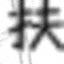

005_U+5782_Yuji-Boku-Regul_28.png


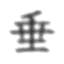

006_U+5F18_Stick-Regular.t_16.png


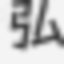

007_U+5098_GenEi-Antique-M_22.png


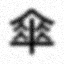

In [8]:
from config import CLASSIFIER_TRAIN_DIR, CLASSIFIER_VAL_DIR, CLASSIFIER_SANITY_DIR
from IPython.display import Image, display

def count_dir(path):
    return len(os.listdir(path)) if os.path.exists(path) else 0

n_classes_train = count_dir(CLASSIFIER_TRAIN_DIR)
n_classes_val   = count_dir(CLASSIFIER_VAL_DIR)
print(f"Classes em train: {n_classes_train} | Classes em val: {n_classes_val}")

sanity_files = sorted(os.listdir(CLASSIFIER_SANITY_DIR))[:8] if os.path.exists(CLASSIFIER_SANITY_DIR) else []
print(f"\nMostrando {len(sanity_files)} amostras sanity:")
for fname in sanity_files:
    print(fname)
    display(Image(os.path.join(CLASSIFIER_SANITY_DIR, fname)))

## 6. Treinar

Chama `src.classifier.train`, que lê os hiperparâmetros do `config.py` (setados na Célula 1).

In [9]:
import subprocess, sys
print("[INFO] Iniciando treino (saida completa abaixo)...")
resultado = subprocess.run([sys.executable, "-m", "src.classifier.train"])
if resultado.returncode != 0:
    raise RuntimeError(f"Treino terminou com codigo de erro {resultado.returncode} -- "
                       f"ver output acima pra diagnosticar.")


[INFO] Iniciando treino (saida completa abaixo)...


## 7. Resultados e curvas

Melhor val_acc: 0.9884 (epoca 4)


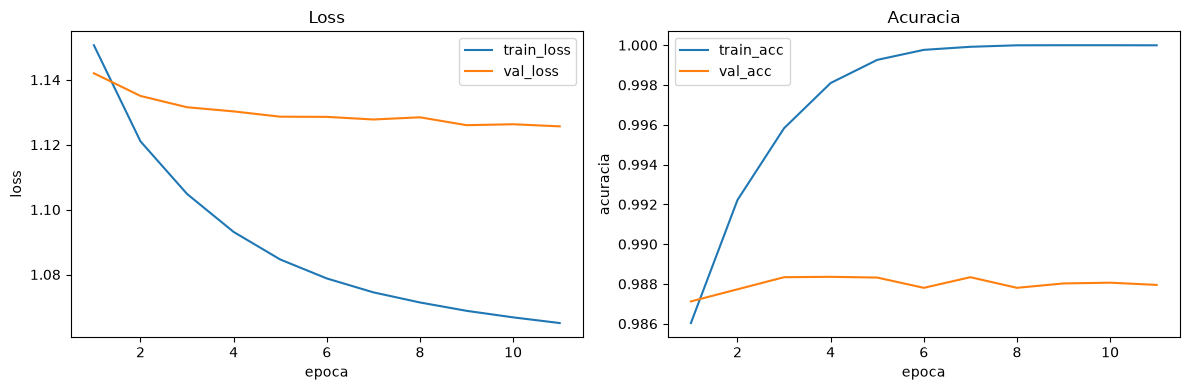

Melhor real_n1_acc: 0.9673 (epoca 11) -- foi esse o criterio do best.pt


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from config import CLF_PROJECT_NAME

RUN_DIR = os.path.join(REPO_DIR, CLF_PROJECT_NAME, "run")
results_csv = os.path.join(RUN_DIR, "results.csv")

df = pd.read_csv(results_csv)
print(f"Melhor val_acc: {df['val_acc'].max():.4f} (epoca {df.loc[df['val_acc'].idxmax(), 'epoch']:.0f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df["epoch"], df["train_loss"], label="train_loss")
axes[0].plot(df["epoch"], df["val_loss"],   label="val_loss")
axes[0].set_xlabel("epoca"); axes[0].set_ylabel("loss"); axes[0].legend(); axes[0].set_title("Loss")

axes[1].plot(df["epoch"], df["train_acc"], label="train_acc")
axes[1].plot(df["epoch"], df["val_acc"],   label="val_acc")
axes[1].set_xlabel("epoca"); axes[1].set_ylabel("acuracia"); axes[1].legend(); axes[1].set_title("Acuracia")

plt.tight_layout()
plt.show()
if "real_n1_acc" in df.columns and df["real_n1_acc"].notna().any():
    idx_best = df["real_n1_acc"].idxmax()
    print(f"Melhor real_n1_acc: {df.loc[idx_best, 'real_n1_acc']:.4f} "
          f"(epoca {df.loc[idx_best, 'epoch']:.0f}) -- foi esse o criterio do best.pt")


## 8. Inspeção visual: predições no conjunto de validação

Carrega o `best.pt` e mostra algumas imagens de validação junto com o kanji predito vs. o real.

C:\Users\migue\AppData\Local\Temp\ipykernel_13076\31175566.py:43: UserWarning: Glyph 35488 (\N{CJK UNIFIED IDEOGRAPH-8AA0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\migue\AppData\Local\Temp\ipykernel_13076\31175566.py:43: UserWarning: Glyph 20161 (\N{CJK UNIFIED IDEOGRAPH-4EC1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\migue\AppData\Local\Temp\ipykernel_13076\31175566.py:43: UserWarning: Glyph 23663 (\N{CJK UNIFIED IDEOGRAPH-5C6F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\migue\AppData\Local\Temp\ipykernel_13076\31175566.py:43: UserWarning: Glyph 36617 (\N{CJK UNIFIED IDEOGRAPH-8F09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\migue\AppData\Local\Temp\ipykernel_13076\31175566.py:43: UserWarning: Glyph 40372 (\N{CJK UNIFIED IDEOGRAPH-9DB4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\migue\AppData\Local\Temp\ipykernel_13076\31175566.py:43: UserWarning: Glyph 21078 (\N{CJK UNIFIE

C:\IC - OCR\Detector-de-kanjis-n1\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 35488 (\N{CJK UNIFIED IDEOGRAPH-8AA0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\IC - OCR\Detector-de-kanjis-n1\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 20161 (\N{CJK UNIFIED IDEOGRAPH-4EC1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\IC - OCR\Detector-de-kanjis-n1\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 23663 (\N{CJK UNIFIED IDEOGRAPH-5C6F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\IC - OCR\Detector-de-kanjis-n1\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 36617 (\N{CJK UNIFIED IDEOGRAPH-8F09}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\IC - OCR\Detector-de-kanjis-n1\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: G

C:\IC - OCR\Detector-de-kanjis-n1\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 27097 (\N{CJK UNIFIED IDEOGRAPH-69D9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


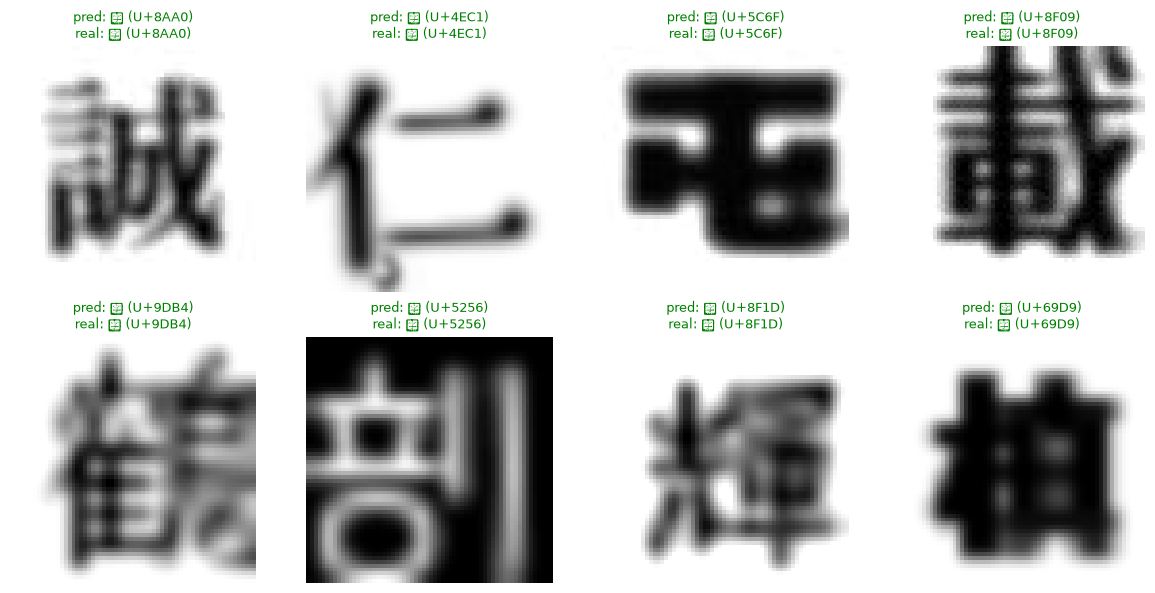

In [11]:
import random
import torch
from PIL import Image as PILImage
import matplotlib.pyplot as plt

from src.classifier.model import build_model
from src.classifier.dataset import build_transform, index_to_kanji
from config import CLASSIFIER_VAL_DIR

best_path = os.path.join(RUN_DIR, "best.pt")
checkpoint = torch.load(best_path, map_location="cpu", weights_only=False)
classes = checkpoint["classes"]

model = build_model(num_classes=len(classes))
model.load_state_dict(checkpoint["model_state"])
model.eval()

transform = build_transform()

# Seleciona algumas imagens aleatorias do val
amostras = []
classes_amostradas = random.sample(classes, min(8, len(classes)))
for cls in classes_amostradas:
    cls_dir = os.path.join(CLASSIFIER_VAL_DIR, cls)
    fname = random.choice(os.listdir(cls_dir))
    amostras.append((os.path.join(cls_dir, fname), cls))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, (img_path, true_cls) in zip(axes.flat, amostras):
    img = PILImage.open(img_path).convert("L")
    x = transform(img).unsqueeze(0)
    with torch.no_grad():
        pred_idx = model(x).argmax(dim=1).item()
    pred_cls = classes[pred_idx]

    acertou = pred_cls == true_cls
    real_char = chr(int(true_cls.replace("U+", ""), 16))
    titulo = f"pred: {index_to_kanji(classes, pred_idx)} ({pred_cls})\nreal: {real_char} ({true_cls})"
    ax.imshow(img, cmap="gray")
    ax.set_title(titulo, color="green" if acertou else "red", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 9. Compactar e baixar

In [12]:
import zipfile
from IPython.display import FileLink, display

zip_name = os.path.join(REPO_DIR, "resultados_classificador.zip") if not IS_KAGGLE else "/kaggle/working/resultados_classificador.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zipf:
    for fname in ["best.pt", "last.pt", "results.csv"]:
        fpath = os.path.join(RUN_DIR, fname)
        if os.path.exists(fpath):
            zipf.write(fpath, fname)
            print(f"{fname} adicionado.")
        else:
            print(f"AVISO: {fname} nao encontrado em {RUN_DIR}")

    config_file = os.path.join(REPO_DIR, "config.py")
    if os.path.exists(config_file):
        zipf.write(config_file, "config.py")
        print("config.py adicionado.")

print(f"\nZip criado: {zip_name}")
display(FileLink(zip_name))

best.pt adicionado.


last.pt adicionado.
results.csv adicionado.
config.py adicionado.

Zip criado: C:\IC - OCR\Detector-de-kanjis-n1\resultados_classificador.zip


C:\IC - OCR\Detector-de-kanjis-n1\resultados_classificador.zip